Created 1/4/2022

Calculate the within cluster variance - based on the lossy compression paper

formula used in paper: 
average circular variance

formula used here: 
sample variance
(notes - we are working with stimuli along a line, so that means the model cannot chunk across the colors on the edges)

want to plot absolute error as function of WCV. and see same thing as figure 4a in paper (as within cluster variance increases, the absolute error increases.)



Notes: if the stimuli have smaller winthin cluster varaince - since there are only 2 sitmuli - then of course the model will do better (because if it has only 1 stimuli in memory, lower error)
so in theory we actually want the WCV to have no effect on the performance in this case. 

BUT if we block the connection of input --> pfc and input --> output and only have input --> chunk, then we may actually see a difference in performance when there is smaller WCV - i mean it could just mean that chunk is storing only one and that isnt great - we actually want to see the shape where the fixed-cont is such that there is 0 at the 0 error and bumps around the center. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()
from decodedoutputdefs import Precision #class with the compiled definitions

In [2]:
def CalcWCV(df_recall, calc = 'var'):
    
#need to extract (based in TrialName) what is under mnt1 and mnt2.

    mnt1 = []
    mnt2 = []
    for t in df_recall['$TrialName']:
        recall = t.split('Recall')[1].split('_')[0]
        if recall == '1':
            mnt1.append(float(t.split('_')[1]))
            mnt2.append(float(t.split('mnt2_')[1].split('_')[0]))
        if recall=='2':
            mnt1.append(float(t.split('mnt1_')[1].split('_')[0]))
            mnt2.append(float(t.split('_')[1]))
            decodeout = df_recall['#OutDecode']
            target = df_recall['#OutTarget']
    
#calculate the variance/diff between the stimuli 
    WCV = []
    perf = []
    perf_mod = []
    stim_diff = 1.5
    for i in range(len(mnt1)):
        if mnt1[i]==-1 or mnt2[i]==-1:
            pass
        else:
            if calc == 'var':
                WCV.append(np.var([mnt1[i],mnt2[i]]))
            if calc == 'diff':
                WCV.append(np.abs(mnt1[i]-mnt2[i]))

            diffrecall =np.array(decodeout)[i]-np.array(target)[i]
            diffrecall_mod = (np.mod(diffrecall+stim_diff/2, stim_diff)-stim_diff/2)

            perf.append(diffrecall)
            perf_mod.append(diffrecall_mod)
    return WCV,perf,perf_mod
        

In [3]:
def binnedaverage(df,xcol,ycol,binwidth = 0.5):
    #x is the values that you want to bin over, y is the responses that will be averaged according to, df is the dataframe
    df = df.sort_values(xcol)
    
    xmin = np.min(df[xcol])
    xmax = np.max(df[xcol])
    bins = np.arange(xmin,xmax,binwidth)
    #np.digitize(df[x],bins = bins)
    WCVbin  = []
    AbsErrbin = []
    AbsErrvar = []
    for uplim in bins[1:]:
        df_temp = pd.DataFrame()
        for row in df.iterrows():
            if row[1][xcol]<uplim:
                df_temp = df_temp.append(row[1])
        TErr,TWCV = df_temp.apply(np.mean,axis = 0)
        TErrvar,TWCVvar = df_temp.apply(np.var,axis = 0)
        WCVbin.append(TWCV)
        AbsErrbin.append(TErr)
        AbsErrvar.append(TErrvar)
    return WCVbin,AbsErrbin, AbsErrvar
            
        #df.apply(checkrow,axis = 1, args = (uplim,xcol, df_temp,df))

    
def checkrow(x,uplim,xcol,df_temp,df):
    if x[xcol]<uplim:
        df_temp = df_temp.append(x)
        #df = df.drop(x.name)
        #import pdb; pdb.set_trace()
        
#df_temp = pd.DataFrame()
#Wdf.apply(checkrow,axis = 1,args=(-12,'logWCV', df_temp,Wdf))

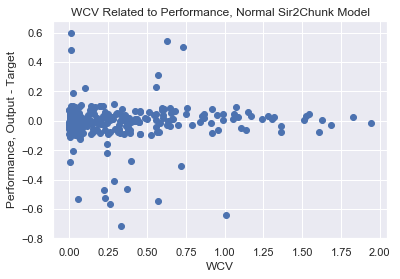

In [68]:
#using data from 3 models that I know are reasonably trained.
#2 stripes
base = "C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir2_chunk/results/"
files = ['base.csv', 'base1.csv', 'base4.csv']
full_files = [base+f for f in files]
p = Precision()
err = p.mult_models(full_files,sep= ',')
p.dat.head()
df_recall = p.dat.loc['True']
WCV,perf,perf_mod = CalcWCV(df_recall,'var')
plt.scatter(WCV,perf_mod)
plt.title('WCV Related to Performance, Normal Sir2Chunk Model')
plt.xlabel('WCV')
plt.ylabel('Performance, Output - Target')
plt.show()

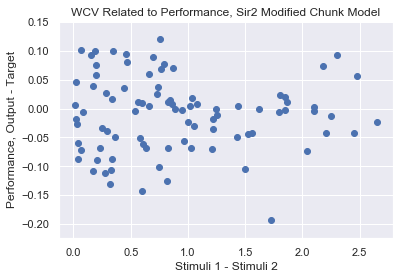

In [107]:
#modified connections, 2 stripes, chunk model
base = "C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir2_chunk/results/"
files = ['baseCheckChunk1.csv']
#files = ['baseCheckChunk.csv', 'baseCheckChunk1.csv','baseCheckChunk2.csv','baseCheckChunk4.csv']
full_files = [base+f for f in files]
p = Precision()
err = p.mult_models(full_files,sep= ',')
p.dat.head()
df_recall = p.dat.loc['True']
WCV,perf,perf_mod = CalcWCV(df_recall,'diff')
plt.scatter(WCV,perf_mod)
plt.title('WCV Related to Performance, Sir2 Modified Chunk Model')
plt.xlabel('WCV')
#plt.xlabel('Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

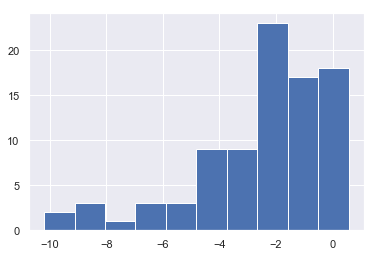

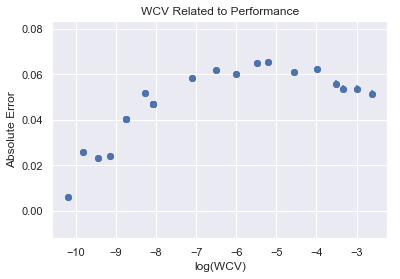

In [106]:
logWCV = np.log(WCV)
n,bins,patches = plt.hist(logWCV, bins = 10)
Wdf = pd.DataFrame({'logWCV': logWCV, 'AbsoluteError':abs(np.array(perf_mod))})
Wdf = Wdf.sort_values('logWCV')
WCVbin,AbsErrbin, AbsErrvar = binnedaverage(Wdf,'logWCV','AbsoluteError')
plt.figure()
plt.scatter(WCVbin,AbsErrbin)
plt.xlabel('log(WCV)')
plt.ylabel('Absolute Error')
plt.title('WCV Related to Performance')
  
plt.errorbar(WCVbin, AbsErrbin, yerr=AbsErrvar, fmt="o")
plt.show()

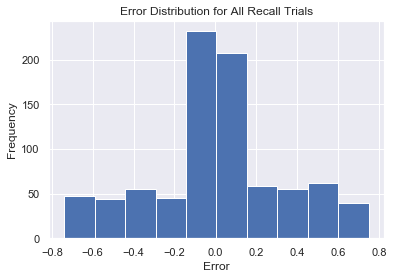

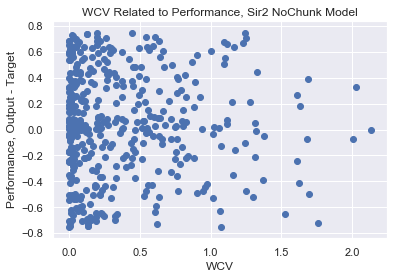

In [15]:
#1 stripe, regular sir2 model
base = "Z:/leabra/examples/workingmemory/sir2_new/results/"
files = ['1Stripemodel0_Base.csv', '1Stripemodel1_Base.csv','1Stripemodel2_Base.csv','1Stripemodel3_Base.csv','1Stripemodel4_Base.csv']
full_files = [base+f for f in files]
p = Precision()
plt.hist(err)
plt.title('Error Distribution for All Recall Trials')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()
err = p.mult_models(full_files)
p.dat.head()
df_recall = p.dat.loc['True']
WCV,perf,perf_mod = CalcWCV(df_recall,'var')
plt.figure()
plt.scatter(WCV,perf_mod)
plt.title('WCV Related to Performance, Sir2 NoChunk Model')
plt.xlabel('WCV')
#plt.xlabel('Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

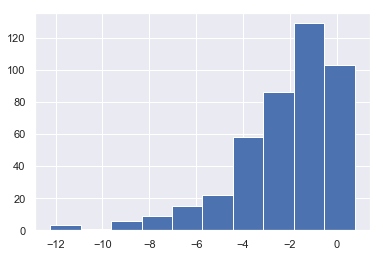

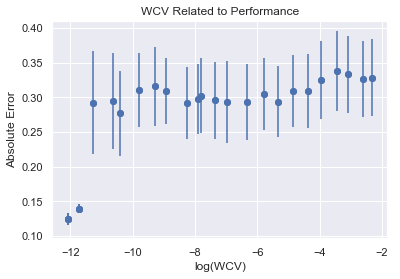

In [16]:
logWCV = np.log(WCV)
n,bins,patches = plt.hist(logWCV, bins = 10)
Wdf = pd.DataFrame({'logWCV': logWCV, 'AbsoluteError':abs(np.array(perf_mod))})
Wdf = Wdf.sort_values('logWCV')
WCVbin,AbsErrbin, AbsErrvar = binnedaverage(Wdf,'logWCV','AbsoluteError')
plt.figure()
plt.scatter(WCVbin,AbsErrbin)
plt.xlabel('log(WCV)')
plt.ylabel('Absolute Error')
plt.title('WCV Related to Performance')
  
plt.errorbar(WCVbin, AbsErrbin, yerr=AbsErrvar, fmt="o")
plt.show()

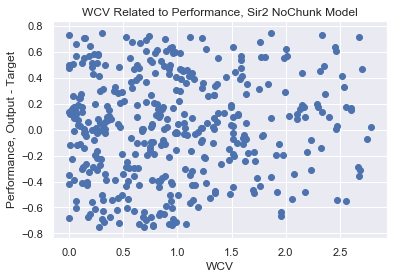

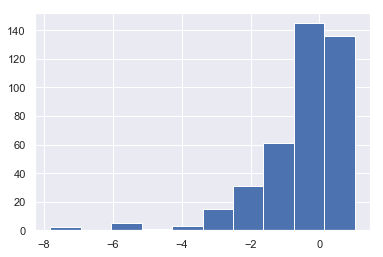

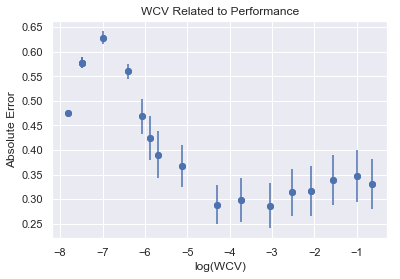

In [8]:
#sir2 hybrid model - input projects to one stripe, chunk projects to the other; chunk receives input from both stripes.
#1 stripe, regular sir2 model
base = "Z:/leabra/examples/workingmemory/sir2_chunk/results/"
files = ['hybridmodel0_Base.csv', 'hybridmodel1_Base.csv','hybridmodel2_Base.csv','hybridmodel3_Base.csv','hybridmodel4_Base.csv']
full_files = [base+f for f in files]
p = Precision()
err = p.mult_models(full_files)
p.dat.head()
df_recall = p.dat.loc['True']
WCV,perf,perf_mod = CalcWCV(df_recall,'diff')
plt.scatter(WCV,perf_mod)
plt.title('WCV Related to Performance, Sir2 NoChunk Model')
plt.xlabel('WCV')
#plt.xlabel('Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

logWCV = np.log(WCV)
n,bins,patches = plt.hist(logWCV, bins = 10)
Wdf = pd.DataFrame({'logWCV': logWCV, 'AbsoluteError':abs(np.array(perf_mod))})
Wdf = Wdf.sort_values('logWCV')
WCVbin,AbsErrbin, AbsErrvar = binnedaverage(Wdf,'logWCV','AbsoluteError')
plt.figure()
plt.scatter(WCVbin,AbsErrbin)
plt.xlabel('log(WCV)')
plt.ylabel('Absolute Error')
plt.title('WCV Related to Performance')
  
plt.errorbar(WCVbin, AbsErrbin, yerr=AbsErrvar, fmt="o")
plt.show()

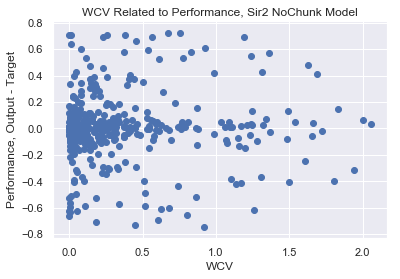

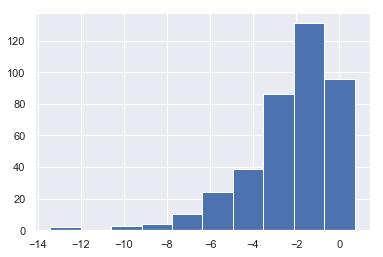

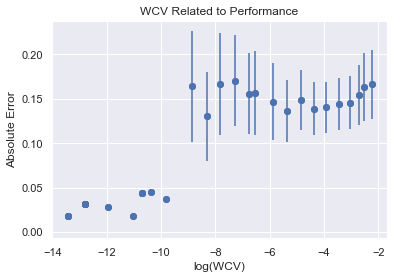

In [10]:
#sir2 hybrid model (gui version) - input projects to one stripe, chunk projects to the other; chunk receives input from both stripes.
#1 stripe, regular sir2 model
base = "C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir2_chunk/results/"
files = ['hybridmodel0.csv', 'hybridmodel1.csv','hybridmodel2.csv','hybridmodel3.csv','hybridmodel4.csv']
full_files = [base+f for f in files]
p = Precision()
err = p.mult_models(full_files,sep=',')
p.dat.head()
df_recall = p.dat.loc['True']
WCV,perf,perf_mod = CalcWCV(df_recall,'var')
plt.scatter(WCV,perf_mod)
plt.title('WCV Related to Performance, Sir2 NoChunk Model')
plt.xlabel('WCV')
#plt.xlabel('Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

logWCV = np.log(WCV)
n,bins,patches = plt.hist(logWCV, bins = 10)
Wdf = pd.DataFrame({'logWCV': logWCV, 'AbsoluteError':abs(np.array(perf_mod))})
Wdf = Wdf.sort_values('logWCV')
WCVbin,AbsErrbin, AbsErrvar = binnedaverage(Wdf,'logWCV','AbsoluteError')
plt.figure()
plt.scatter(WCVbin,AbsErrbin)
plt.xlabel('log(WCV)')
plt.ylabel('Absolute Error')
plt.title('WCV Related to Performance')
  
plt.errorbar(WCVbin, AbsErrbin, yerr=AbsErrvar, fmt="o")
plt.show()

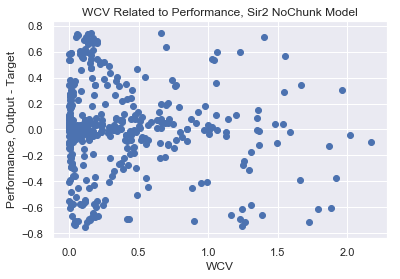

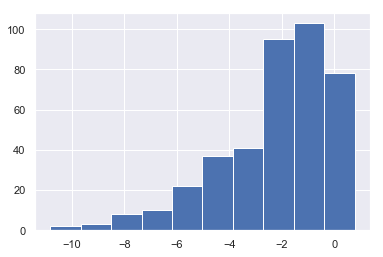

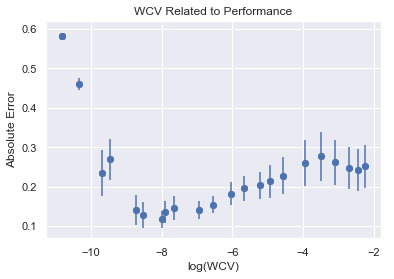

In [11]:
#sir2 hybrid model (gui version) - input projects to one stripe, chunk projects to the other; chunk receives input from both stripes.
#1 stripe, regular sir2 model; 
#No input stripe during testing.
base = "C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir2_chunk/results/"
files = ['hybridNoInputmodel0.csv', 'hybridNoInputmodel1.csv','hybridNoInputmodel2.csv','hybridNoInputmodel3.csv','hybridNoInputmodel4.csv']
full_files = [base+f for f in files]
p = Precision()
err = p.mult_models(full_files,sep=',')
p.dat.head()
df_recall = p.dat.loc['True']
WCV,perf,perf_mod = CalcWCV(df_recall,'var')
plt.scatter(WCV,perf_mod)
plt.title('WCV Related to Performance, Sir2 NoChunk Model')
plt.xlabel('WCV')
#plt.xlabel('Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

logWCV = np.log(WCV)
n,bins,patches = plt.hist(logWCV, bins = 10)
Wdf = pd.DataFrame({'logWCV': logWCV, 'AbsoluteError':abs(np.array(perf_mod))})
Wdf = Wdf.sort_values('logWCV')
WCVbin,AbsErrbin, AbsErrvar = binnedaverage(Wdf,'logWCV','AbsoluteError')
plt.figure()
plt.scatter(WCVbin,AbsErrbin)
plt.xlabel('log(WCV)')
plt.ylabel('Absolute Error')
plt.title('WCV Related to Performance')
  
plt.errorbar(WCVbin, AbsErrbin, yerr=AbsErrvar, fmt="o")
plt.show()

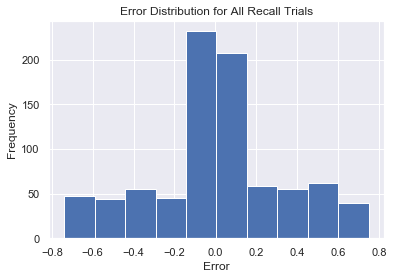

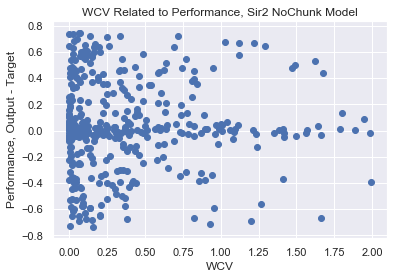

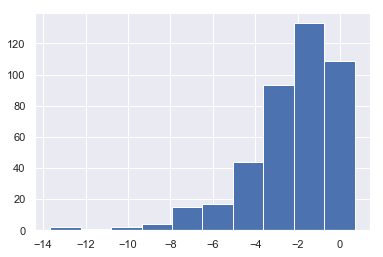

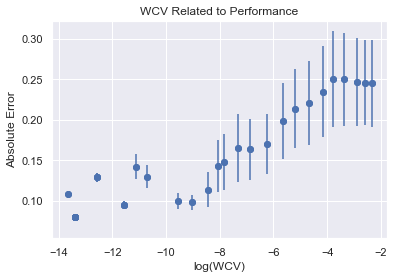

In [13]:
#sir2 hybrid model (gui version) - input projects to one stripe, chunk projects to the other; chunk receives input from both stripes.
#1 stripe, regular sir2 model; 
#No chunk stripe during testing.
base = "C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir2_chunk/results/"
files = ['hybridNoChunkmodel0.csv', 'hybridNoChunkmodel1.csv','hybridNoChunkmodel2.csv','hybridNoChunkmodel3.csv','hybridNoChunkmodel4.csv']
full_files = [base+f for f in files]
p = Precision()
err = p.mult_models(full_files,sep=',')
plt.hist(err)
plt.title('Error Distribution for All Recall Trials')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()
p.dat.head()
df_recall = p.dat.loc['True']
WCV,perf,perf_mod = CalcWCV(df_recall,'var')
plt.figure()
plt.scatter(WCV,perf_mod)
plt.title('WCV Related to Performance, Sir2 NoChunk Model')
plt.xlabel('WCV')
#plt.xlabel('Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

logWCV = np.log(WCV)
n,bins,patches = plt.hist(logWCV, bins = 10)
Wdf = pd.DataFrame({'logWCV': logWCV, 'AbsoluteError':abs(np.array(perf_mod))})
Wdf = Wdf.sort_values('logWCV')
WCVbin,AbsErrbin, AbsErrvar = binnedaverage(Wdf,'logWCV','AbsoluteError')
plt.figure()
plt.scatter(WCVbin,AbsErrbin)
plt.xlabel('log(WCV)')
plt.ylabel('Absolute Error')
plt.title('WCV Related to Performance')
  
plt.errorbar(WCVbin, AbsErrbin, yerr=AbsErrvar, fmt="o")
plt.show()

In [5]:
#using data from 3 models that I know are reasonably trained.
base = "C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir2_chunk/results/"
files = ['base.csv', 'base1.csv', 'base4.csv']
full_files = [base+f for f in files]

In [6]:
p = Precision()
err = p.mult_models(full_files,sep= ',')

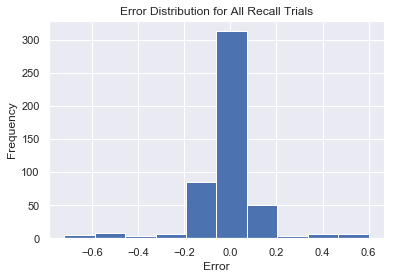

In [7]:
plt.hist(err)
plt.title('Error Distribution for All Recall Trials')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()

In [8]:
p.dat.head()
df_recall = p.dat.loc['True']

In [9]:
df_recall.head()

,|Run,|Epoch,|Trial,$TrialName,#Err,#SSE,#AvgSSE,#CosDiff,#DA,#AbsDA,...,"#PFCoutD[4:1,0,0,19]",#stripe,#stripe,#OutDecode,#OutTarget,#InDecode,#ChunkDecode,$Lesion,#LesionProp,$LesionApplied
True,0,-1,2,Recall1_3.353433954079331_mnt1_-1_mnt2_-1_rew_1,1,0.2858,0.01429,0.9068,0.05,0.05,...,1.401000e-45,3.308,0.000,3.292,3.301,0.0,0.0,None,0,no
True,0,-1,4,Recall1_3.246803479572182_mnt1_-1_mnt2_-1_rew_1,1,0.2885,0.01442,0.9044,0.05,0.05,...,1.401000e-45,3.292,0.000,3.286,3.212,0.0,0.0,None,0,no
True,0,-1,6,Recall1_3.1403944672231088_mnt1_-1_mnt2_-1_rew_1,1,0.2716,0.01358,0.9024,0.05,0.05,...,1.401000e-45,3.107,0.000,3.110,3.131,0.0,0.0,None,0,no
True,0,-1,13,Recall1_3.1498523363610005_mnt1_-1_mnt2_2.2024...,1,0.2864,0.01432,0.9008,0.05,0.05,...,1.401000e-45,3.107,2.203,3.110,3.138,0.0,0.0,None,0,no
True,0,-1,15,Recall2_2.2024977931521255_mnt1_-1_mnt2_-1_rew_1,0,0.0000,0.00000,0.9533,0.05,0.05,...,1.401000e-45,3.107,0.000,2.208,2.202,0.0,0.0,None,0,no


#realize that the when there is a recall trial - if recall1, then mnt1 will become -1 and so need to also use recall1/recall2 and the
following info to fill in the wcv.

In [10]:
#need to extract (based in TrialName) what is under mnt1 and mnt2.

mnt1 = []
mnt2 = []
for t in df_recall['$TrialName']:
    recall = t.split('Recall')[1].split('_')[0]
    if recall == '1':
        mnt1.append(float(t.split('_')[1]))
        mnt2.append(float(t.split('mnt2_')[1].split('_')[0]))
    if recall=='2':
        mnt1.append(float(t.split('mnt1_')[1].split('_')[0]))
        mnt2.append(float(t.split('_')[1]))
        decodeout = df_recall['#OutDecode']
        target = df_recall['#OutTarget']
    
WCV = []
perf = []
perf_mod = []
stim_diff = 1.5
for i in range(len(mnt1)):
    if mnt1[i]==-1 or mnt2[i]==-1:
        pass
    else:
        #WCV.append(np.abs(mnt1[i]-mnt2[i]))
        WCV.append(np.var([mnt1[i],mnt2[i]]))
        
        diffrecall =np.array(decodeout)[i]-np.array(target)[i]
        diffrecall_mod = (np.mod(diffrecall+stim_diff/2, stim_diff)-stim_diff/2)
        
        perf.append(diffrecall)
        perf_mod.append(diffrecall_mod)
        
    #if np.logical_and(mnt1[i]!= -1, mnt2[i]!= -1):
    #    WCV.append(mnt1[i]*mnt2[i])
        

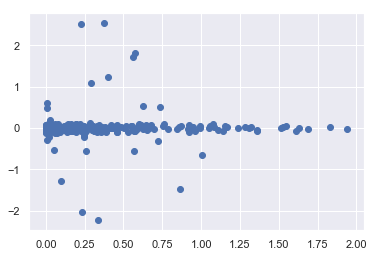

In [11]:
plt.scatter(WCV,perf)

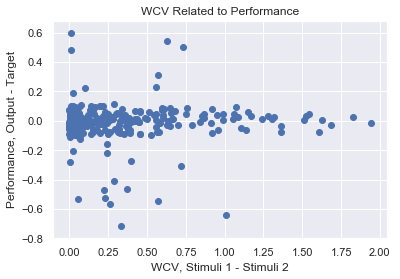

In [12]:
plt.scatter(WCV,perf_mod)
plt.title('WCV Related to Performance')
plt.xlabel('WCV, Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

This is what we expect - no diff in perf regardless of where we are in the WCV

Now do it without the input projecting to output, pfc or hidden.and add a projection from chunk to output.
then run the models and only pick the ones that are performing okay. 

In [85]:
base = "C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir2_chunk/results/"
#files = ['baseCheckChunk.csv']
files = ['baseCheckChunk.csv', 'baseCheckChunk1.csv','baseCheckChunk2.csv','baseCheckChunk3.csv','baseCheckChunk4.csv']
full_files = [base+f for f in files]

In [86]:
full_files[0]

'C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir2_chunk/results/baseCheckChunk.csv'

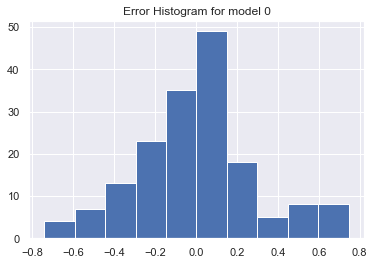

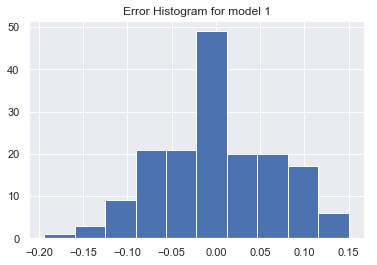

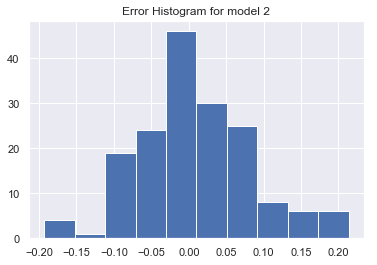

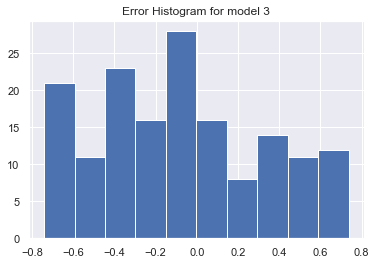

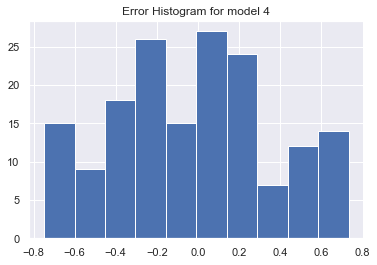

In [87]:
#plotting errors for each model
for i in range(len(full_files)):
    plt.figure()
    rel = Precision()
    diffrecall = rel.mult_models([full_files[i]], sep=',')
    plt.hist(diffrecall)
    plt.title('Error Histogram for model ' + str(i))

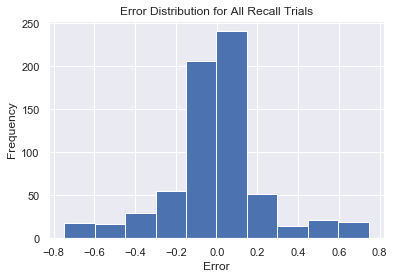

In [85]:
#plotting WCV for the models that have reasonable errors. 

base = "C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir2_chunk/results/"
#model 0 and model 3 and 4 do not seem good.
#files = ['baseCheckChunk1.csv','baseCheckChunk2.csv']

files = ['baseCheckChunk.csv', 'baseCheckChunk1.csv','baseCheckChunk2.csv','baseCheckChunk4.csv']
full_files = [base+f for f in files]
p = Precision()
err = p.mult_models(full_files,sep= ',')
p.dat.head()
df_recall = p.dat.loc['True']
plt.hist(err)
plt.title('Error Distribution for All Recall Trials')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()

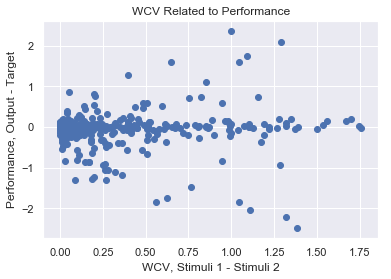

In [86]:
#need to extract (based in TrialName) what is under mnt1 and mnt2.

mnt1 = []
mnt2 = []
for t in df_recall['$TrialName']:
    recall = t.split('Recall')[1].split('_')[0]
    if recall == '1':
        mnt1.append(float(t.split('_')[1]))
        mnt2.append(float(t.split('mnt2_')[1].split('_')[0]))
    if recall=='2':
        mnt1.append(float(t.split('mnt1_')[1].split('_')[0]))
        mnt2.append(float(t.split('_')[1]))
        decodeout = df_recall['#OutDecode']
        target = df_recall['#OutTarget']
    
WCV = []
perf = []
perf_mod = []
stim_diff = 1.5
for i in range(len(mnt1)):
    if mnt1[i]==-1 or mnt2[i]==-1:
        pass
    else:
        #WCV.append(np.abs(mnt1[i]-mnt2[i]))
        WCV.append(np.var([mnt1[i],mnt2[i]]))
        
        diffrecall =np.array(decodeout)[i]-np.array(target)[i]
        diffrecall_mod = (np.mod(diffrecall+stim_diff/2, stim_diff)-stim_diff/2)
        
        perf.append(diffrecall)
        perf_mod.append(diffrecall_mod)
        
    #if np.logical_and(mnt1[i]!= -1, mnt2[i]!= -1):
    #    WCV.append(mnt1[i]*mnt2[i])
plt.scatter(WCV,perf)
plt.title('WCV Related to Performance')
plt.xlabel('WCV, Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

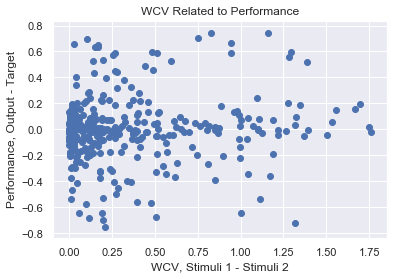

In [87]:
plt.scatter(WCV,perf_mod)
plt.title('WCV Related to Performance')
plt.xlabel('WCV, Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

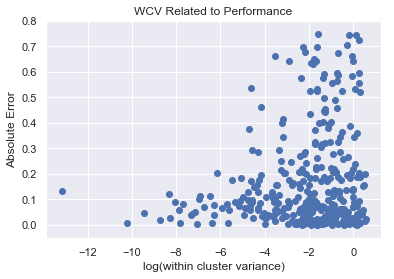

In [88]:
plt.scatter(np.log(WCV),abs(np.array(perf_mod)))
plt.title('WCV Related to Performance')
plt.xlabel('log(within cluster variance)')
plt.ylabel('Absolute Error')
plt.show()

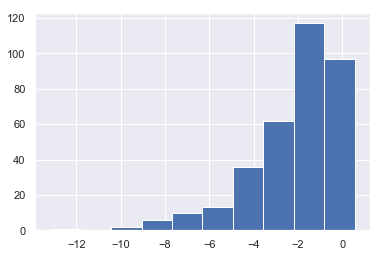

In [89]:
logWCV = np.log(WCV)
n,bins,patches = plt.hist(logWCV, bins = 10)

In [90]:
Wdf = pd.DataFrame({'logWCV': logWCV, 'AbsoluteError':abs(np.array(perf_mod))})
Wdf = Wdf.sort_values('logWCV')

In [91]:
len(Wdf)

344

In [92]:
def binnedaverage(df,xcol,ycol,binwidth = 0.5):
    #x is the values that you want to bin over, y is the responses that will be averaged according to, df is the dataframe
    df = df.sort_values(xcol)
    
    xmin = np.min(df[xcol])
    xmax = np.max(df[xcol])
    bins = np.arange(xmin,xmax,binwidth)
    #np.digitize(df[x],bins = bins)
    WCVbin  = []
    AbsErrbin = []
    AbsErrvar = []
    for uplim in bins[1:]:
        df_temp = pd.DataFrame()
        for row in df.iterrows():
            if row[1][xcol]<uplim:
                df_temp = df_temp.append(row[1])
        TErr,TWCV = df_temp.apply(np.mean,axis = 0)
        TErrvar,TWCVvar = df_temp.apply(np.var,axis = 0)
        WCVbin.append(TWCV)
        AbsErrbin.append(TErr)
        AbsErrvar.append(TErrvar)
    return WCVbin,AbsErrbin, AbsErrvar
            
        #df.apply(checkrow,axis = 1, args = (uplim,xcol, df_temp,df))

    
def checkrow(x,uplim,xcol,df_temp,df):
    if x[xcol]<uplim:
        df_temp = df_temp.append(x)
        #df = df.drop(x.name)
        #import pdb; pdb.set_trace()
        
#df_temp = pd.DataFrame()
#Wdf.apply(checkrow,axis = 1,args=(-12,'logWCV', df_temp,Wdf))

(array([153.,  65.,  45.,  17.,  13.,  12.,   6.,  16.,   8.,   9.]),
 array([0.     , 0.07482, 0.14964, 0.22446, 0.29928, 0.3741 , 0.44892,
        0.52374, 0.59856, 0.67338, 0.7482 ]),
 <a list of 10 Patch objects>)

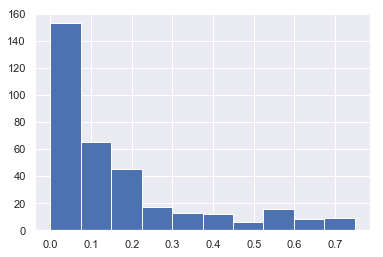

In [93]:
plt.hist(Wdf['AbsoluteError'])

In [94]:
WCVbin,AbsErrbin, AbsErrvar = binnedaverage(Wdf,'logWCV','AbsoluteError')

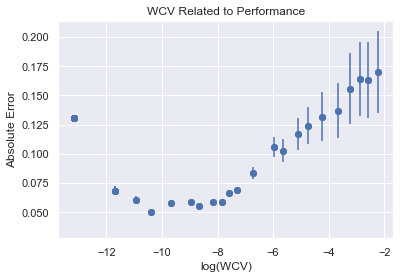

In [95]:
plt.scatter(WCVbin,AbsErrbin)
plt.xlabel('log(WCV)')
plt.ylabel('Absolute Error')
plt.title('WCV Related to Performance')
  
plt.errorbar(WCVbin, AbsErrbin, yerr=AbsErrvar, fmt="o")
plt.show()

The results above are as okay - we can see the trend
plan
1)lets plot just the trials where the first item is the one recalled.- how we will do this - look at recall slides and then look at the original df (not just recall df) called self.dat
- trial name - search in the original df, then look at the trial number that trial name is and then look at trials before one at a time until find a store trial. whichever the store trial is, the recall should be the opposite to keep that trial for plotting.

shoot this isn't that simple because there are 4 models so there are multiple trial numbers. maybe use orignal index (not the true/false), then this won't be a problme.
congruent trial - second store and recall trials are the same (i.e. store2 and recall2) 
assymetric trial - second store and recall trial are different.
2)we want to check that the the item stored in the chunk is an average/some combination of the two stimuli and not just one or the other.

In [9]:
df_original = p.dat
df_original.index=range(len(df_original))
df_original.head()

,|Run,|Epoch,|Trial,$TrialName,#Err,#SSE,#AvgSSE,#CosDiff,#DA,#AbsDA,...,"#PFCoutD[4:1,0,0,19]",#stripe,#stripe,#OutDecode,#OutTarget,#InDecode,#ChunkDecode,$Lesion,#LesionProp,$LesionApplied
0,0,-1,0,Store2_2.155653281124616_mnt1_-1_mnt2_2.155653...,0,0.0000,0.00000,0.9539,0.00,0.00,...,1.401000e-45,2.139,2.192,2.137,2.162,2.162,2.148,None,0,no
1,0,-1,1,Store1_1.4785210654300842_mnt1_1.4785210654300...,1,1.7770,0.08883,0.4241,0.00,0.00,...,1.401000e-45,2.160,1.502,1.882,1.483,1.484,1.489,None,0,no
2,0,-1,2,Ignore_3.094438387967364_mnt1_1.47852106543008...,0,0.0000,0.00000,0.8501,0.00,0.00,...,1.401000e-45,2.160,1.501,2.894,3.096,3.096,3.097,None,0,no
3,0,-1,3,Ignore_1.0362751431046162_mnt1_1.4785210654300...,1,0.2930,0.01465,0.7889,0.00,0.00,...,1.401000e-45,2.160,1.501,1.268,1.031,1.031,1.099,None,0,no
4,0,-1,4,Recall1_1.4785210654300842_mnt1_-1_mnt2_2.1556...,1,0.7893,0.03946,0.8075,0.05,0.05,...,1.401000e-45,2.160,1.501,1.404,1.483,0.000,0.000,None,0,no


In [10]:
store = 'Store' in df_original.iloc[3]['$TrialName']

In [11]:
df_original[df_original['$TrialName']=='Store2_2.155653281124616_mnt1_-1_mnt2_2.155653281124616_rew_0'].index[0]

0

In [12]:
df_original.iloc[2]['$TrialName']

'Ignore_3.094438387967364_mnt1_1.4785210654300842_mnt2_2.155653281124616_rew_0'

In [15]:
def cong(df_recall,df_original):
    keeprecalltrial =[]
    removerecalltrial = []
    for tr in df_recall['$TrialName']:
        trialnum = df_original[df_original['$TrialName']==tr].index[0]
        storetrial = trialnum-1
        recall_type = tr.split('Recall')[1].split('_')[0]
        Store = 'NotFound'
        while Store == 'NotFound':
            store = 'Store' in df_original.iloc[storetrial]['$TrialName']
            if store == True:
                storenum = df_original.iloc[storetrial]['$TrialName'].split('Store')[1].split('_')[0]
                if storenum == recall_type:
                    removerecalltrial.append(tr)
                if storenum != recall_type:
                    keeprecalltrial.append(tr)
                Store = 'Found'
                break
            else:
                storetrial = storetrial-1
    return (keeprecalltrial,removerecalltrial)
            
        

there are 267 keep trials, but only 126 have been found in the recall trials..........
they have to be in the original df_recall because to generate the keeptrials, i used the TrialName to iterate over.

this problem solved for now just make sure you are using the correct df_recall when pulling out.

In [16]:
k,r = cong(df_recall,df_original)

In [61]:
#now we have recall trials that are keep (k) or remove (r)

df_recall_keep = pd.DataFrame()
for kt in k:
    df_recall_keep = df_recall_keep.append(df_recall[df_recall['$TrialName']==kt])

In [62]:
len(df_recall_keep)

267

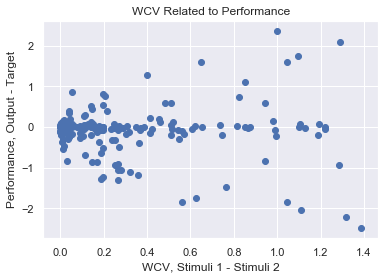

In [63]:
#need to extract (based in TrialName) what is under mnt1 and mnt2.

mnt1 = []
mnt2 = []
for t in df_recall_keep['$TrialName']:
    recall = t.split('Recall')[1].split('_')[0]
    if recall == '1':
        mnt1.append(float(t.split('_')[1]))
        mnt2.append(float(t.split('mnt2_')[1].split('_')[0]))
    if recall=='2':
        mnt1.append(float(t.split('mnt1_')[1].split('_')[0]))
        mnt2.append(float(t.split('_')[1]))
        decodeout = df_recall_keep['#OutDecode']
        target = df_recall_keep['#OutTarget']
    
WCV = []
perf = []
perf_mod = []
stim_diff = 1.5
for i in range(len(mnt1)):
    if mnt1[i]==-1 or mnt2[i]==-1:
        pass
    else:
        #WCV.append(np.abs(mnt1[i]-mnt2[i]))
        WCV.append(np.var([mnt1[i],mnt2[i]]))
        
        diffrecall =np.array(decodeout)[i]-np.array(target)[i]
        diffrecall_mod = (np.mod(diffrecall+stim_diff/2, stim_diff)-stim_diff/2)
        
        perf.append(diffrecall)
        perf_mod.append(diffrecall_mod)
        
    #if np.logical_and(mnt1[i]!= -1, mnt2[i]!= -1):
    #    WCV.append(mnt1[i]*mnt2[i])
plt.scatter(WCV,perf)
plt.title('WCV Related to Performance')
plt.xlabel('WCV, Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

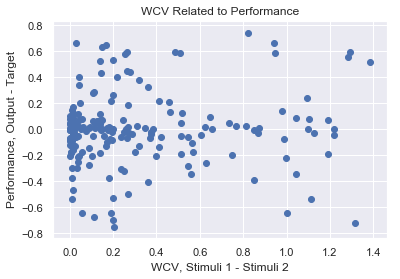

In [64]:
plt.scatter(WCV,perf_mod)
plt.title('WCV Related to Performance')
plt.xlabel('WCV, Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

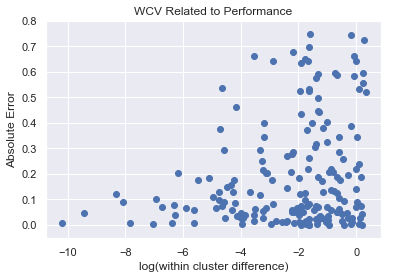

In [65]:
plt.scatter(np.log(WCV),abs(np.array(perf_mod)))
plt.title('WCV Related to Performance')
plt.xlabel('log(within cluster difference)')
plt.ylabel('Absolute Error')
plt.show()

In [67]:
df_recall_remove = pd.DataFrame()
for rt in r:
    df_recall_remove = df_recall_remove.append(df_recall[df_recall['$TrialName']==rt])

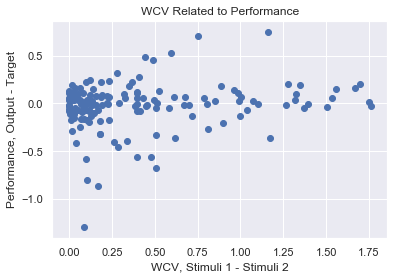

In [68]:
#need to extract (based in TrialName) what is under mnt1 and mnt2.

mnt1 = []
mnt2 = []
for t in df_recall_remove['$TrialName']:
    recall = t.split('Recall')[1].split('_')[0]
    if recall == '1':
        mnt1.append(float(t.split('_')[1]))
        mnt2.append(float(t.split('mnt2_')[1].split('_')[0]))
    if recall=='2':
        mnt1.append(float(t.split('mnt1_')[1].split('_')[0]))
        mnt2.append(float(t.split('_')[1]))
        decodeout = df_recall_remove['#OutDecode']
        target = df_recall_remove['#OutTarget']
    
WCV = []
perf = []
perf_mod = []
stim_diff = 1.5
for i in range(len(mnt1)):
    if mnt1[i]==-1 or mnt2[i]==-1:
        pass
    else:
        #WCV.append(np.abs(mnt1[i]-mnt2[i]))
        WCV.append(np.var([mnt1[i],mnt2[i]]))
        
        diffrecall =np.array(decodeout)[i]-np.array(target)[i]
        diffrecall_mod = (np.mod(diffrecall+stim_diff/2, stim_diff)-stim_diff/2)
        
        perf.append(diffrecall)
        perf_mod.append(diffrecall_mod)
        
    #if np.logical_and(mnt1[i]!= -1, mnt2[i]!= -1):
    #    WCV.append(mnt1[i]*mnt2[i])
plt.scatter(WCV,perf)
plt.title('WCV Related to Performance')
plt.xlabel('WCV, Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

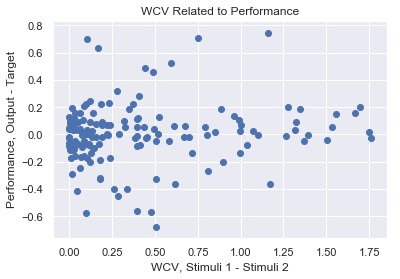

In [69]:
plt.scatter(WCV,perf_mod)
plt.title('WCV Related to Performance')
plt.xlabel('WCV, Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

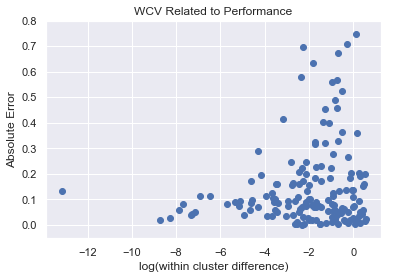

In [70]:
plt.scatter(np.log(WCV),abs(np.array(perf_mod)))
plt.title('WCV Related to Performance')
plt.xlabel('log(within cluster difference)')
plt.ylabel('Absolute Error')
plt.show()

Above we checked the wcv by shutting of input; 
now we will check chunking with 1 stripe (turn on connection between input and output etc., turn off connection between chunk -->output) normal conectivity
results are on oscar

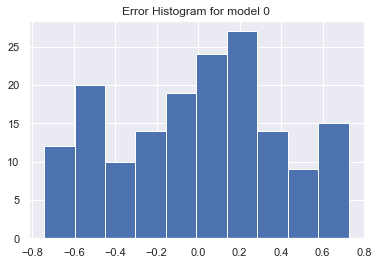

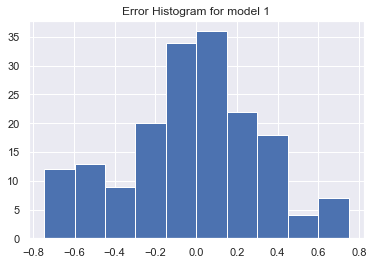

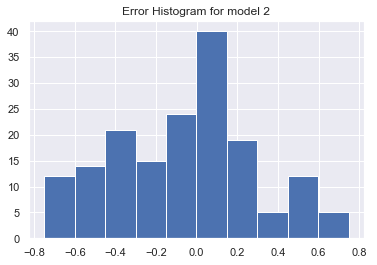

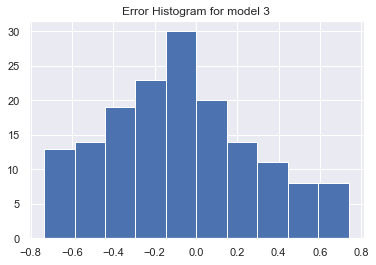

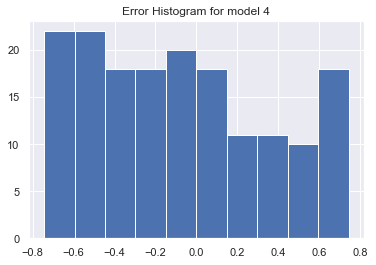

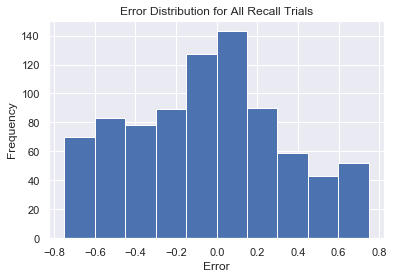

In [78]:
#plotting WCV for the models that have reasonable errors. 

base = "Z:/leabra/examples/workingmemory/sir2_chunk/results/"
files = ['1Stripemodel0_Base.csv', '1Stripemodel1_Base.csv','1Stripemodel2_Base.csv','1Stripemodel3_Base.csv','1Stripemodel4_Base.csv']
full_files = [base+f for f in files]

#plotting errors for each model
for i in range(len(full_files)):
    plt.figure()
    rel = Precision()
    diffrecall = rel.mult_models([full_files[i]])
    plt.hist(diffrecall)
    plt.title('Error Histogram for model ' + str(i))

p = Precision()
err = p.mult_models(full_files)
p.dat.head()
df_recall = p.dat.loc['True']
plt.figure()
plt.hist(err)
plt.title('Error Distribution for All Recall Trials')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()

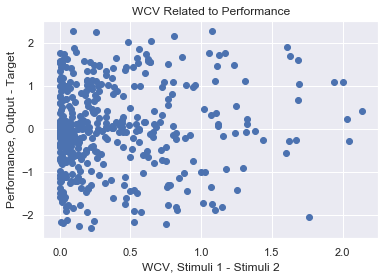

In [79]:
#need to extract (based in TrialName) what is under mnt1 and mnt2.

mnt1 = []
mnt2 = []
for t in df_recall['$TrialName']:
    recall = t.split('Recall')[1].split('_')[0]
    if recall == '1':
        mnt1.append(float(t.split('_')[1]))
        mnt2.append(float(t.split('mnt2_')[1].split('_')[0]))
    if recall=='2':
        mnt1.append(float(t.split('mnt1_')[1].split('_')[0]))
        mnt2.append(float(t.split('_')[1]))
        decodeout = df_recall['#OutDecode']
        target = df_recall['#OutTarget']
    
WCV = []
perf = []
perf_mod = []
stim_diff = 1.5
for i in range(len(mnt1)):
    if mnt1[i]==-1 or mnt2[i]==-1:
        pass
    else:
        #WCV.append(np.abs(mnt1[i]-mnt2[i]))
        WCV.append(np.var([mnt1[i],mnt2[i]]))
        
        diffrecall =np.array(decodeout)[i]-np.array(target)[i]
        diffrecall_mod = (np.mod(diffrecall+stim_diff/2, stim_diff)-stim_diff/2)
        
        perf.append(diffrecall)
        perf_mod.append(diffrecall_mod)
        
    #if np.logical_and(mnt1[i]!= -1, mnt2[i]!= -1):
    #    WCV.append(mnt1[i]*mnt2[i])
plt.scatter(WCV,perf)
plt.title('WCV Related to Performance')
plt.xlabel('WCV, Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

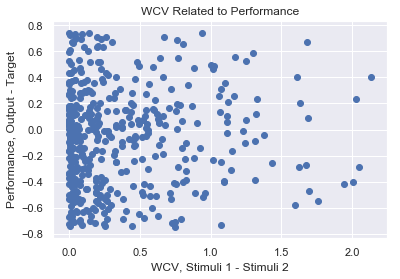

In [80]:
plt.scatter(WCV,perf_mod)
plt.title('WCV Related to Performance')
plt.xlabel('WCV, Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()

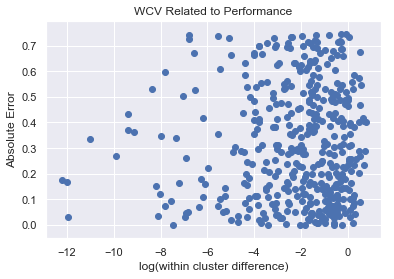

In [81]:
plt.scatter(np.log(WCV),abs(np.array(perf_mod)))
plt.title('WCV Related to Performance')
plt.xlabel('log(within cluster difference)')
plt.ylabel('Absolute Error')
plt.show()

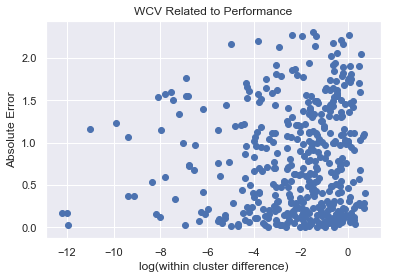

In [82]:
plt.scatter(np.log(WCV),abs(np.array(perf)))
plt.title('WCV Related to Performance')
plt.xlabel('log(within cluster difference)')
plt.ylabel('Absolute Error')
plt.show()

In [ ]:
#model with no chunk layer

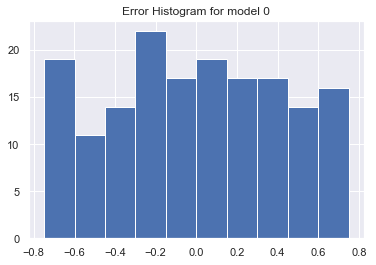

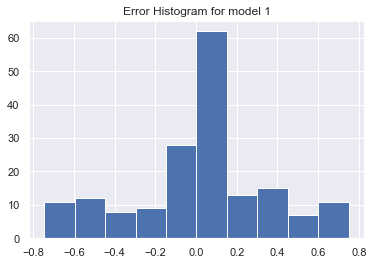

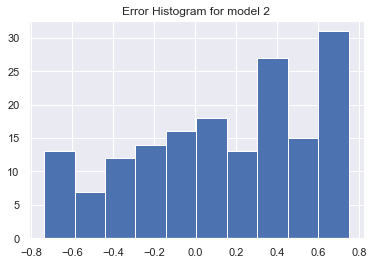

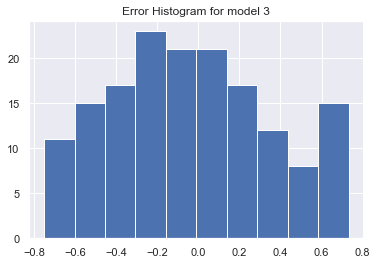

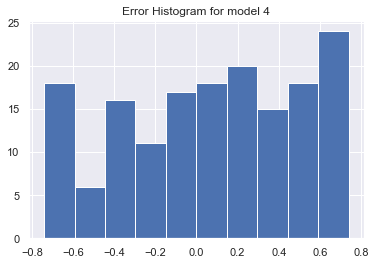

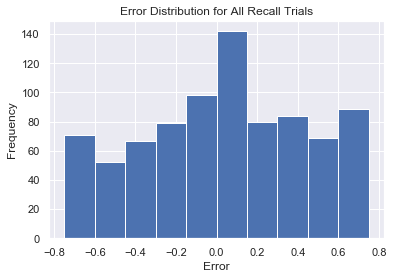

In [83]:
#plotting WCV for the models that have reasonable errors. 

base = "Z:/leabra/examples/workingmemory/sir2_new/results/"
files = ['1Stripemodel0_Base.csv', '1Stripemodel1_Base.csv','1Stripemodel2_Base.csv','1Stripemodel3_Base.csv','1Stripemodel4_Base.csv']
full_files = [base+f for f in files]

#plotting errors for each model
for i in range(len(full_files)):
    plt.figure()
    rel = Precision()
    diffrecall = rel.mult_models([full_files[i]])
    plt.hist(diffrecall)
    plt.title('Error Histogram for model ' + str(i))

p = Precision()
err = p.mult_models(full_files)
p.dat.head()
df_recall = p.dat.loc['True']
plt.figure()
plt.hist(err)
plt.title('Error Distribution for All Recall Trials')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()

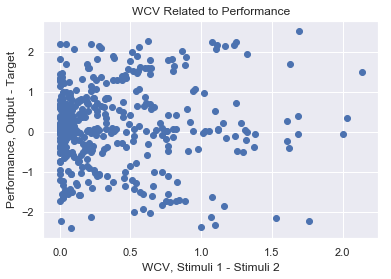

In [84]:
#need to extract (based in TrialName) what is under mnt1 and mnt2.

mnt1 = []
mnt2 = []
for t in df_recall['$TrialName']:
    recall = t.split('Recall')[1].split('_')[0]
    if recall == '1':
        mnt1.append(float(t.split('_')[1]))
        mnt2.append(float(t.split('mnt2_')[1].split('_')[0]))
    if recall=='2':
        mnt1.append(float(t.split('mnt1_')[1].split('_')[0]))
        mnt2.append(float(t.split('_')[1]))
        decodeout = df_recall['#OutDecode']
        target = df_recall['#OutTarget']
    
WCV = []
perf = []
perf_mod = []
stim_diff = 1.5
for i in range(len(mnt1)):
    if mnt1[i]==-1 or mnt2[i]==-1:
        pass
    else:
        #WCV.append(np.abs(mnt1[i]-mnt2[i]))
        WCV.append(np.var([mnt1[i],mnt2[i]]))
        
        diffrecall =np.array(decodeout)[i]-np.array(target)[i]
        diffrecall_mod = (np.mod(diffrecall+stim_diff/2, stim_diff)-stim_diff/2)
        
        perf.append(diffrecall)
        perf_mod.append(diffrecall_mod)
        
    #if np.logical_and(mnt1[i]!= -1, mnt2[i]!= -1):
    #    WCV.append(mnt1[i]*mnt2[i])
plt.scatter(WCV,perf)
plt.title('WCV Related to Performance')
plt.xlabel('WCV, Stimuli 1 - Stimuli 2')
plt.ylabel('Performance, Output - Target')
plt.show()